<font size="10" color="DarkSlateGray"><b>Simple Road Follower</b></font>

This notebook accompanies the Medium article [**“A Modern Workflow for ROS Development Using Google Colab and Foxglove”**](https://medium.com/@engelwilliam97/)


<img src="https://drive.google.com/uc?export=view&id=1u71bvuqnuzD8EgT6Jqq6frWwM7W1PnHP" width="1000">

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob

## ℹ️ How to use the Colab notebook

### 1) Connections

In the **Connections** section, the notebook is linked to both **Google Drive** and **Foxglove Cloud**.

* **Connect to Google Drive**
  Update the path so it points to your own workspace inside Google Drive. This is where datasets and exported files will be stored.

* **Connect to Foxglove**
  Set your **Foxglove API key** in Google Colab **Secrets**. Once this is done, the *Connect to Foxglove* cell can access your Foxglove recordings via Foxflow.

---

### 2) Getting the data into Colab

In **Streaming Foxglove data into Colab**, we use Foxflow with Foxglove Cloud.

Upload the bagfiles to your Foxglove account and stream them directly into Colab using Foxflow.

Dataset: [Foxglove Upload Dataset — Click here](https://drive.google.com/file/d/1QNpb-5RUeVgS_tCsKBbQe3wq2cpP1PiH/view?usp=sharing)

*Note:*

Make sure your FOXGLOVE_KEY is set correctly.  
You can then directly read topics (e.g. camera, masks, steering).

---

### 3) Verify the data

In the **Quick look at the data** section, verify that images and steering commands look reasonable. This confirms that Foxflow, Colab, and the dataset are correctly connected.

---

### 4) Continue with the notebook

Once the data looks correct, continue with the rest of the notebook to analyze the data, build the pipeline, and develop the driving algorithm.


## Connections

In [2]:
import os
from google.colab import drive, userdata
from pathlib import Path

**Connect to Google Drive**

In [3]:
# Connect to Google Drive
if not Path("/content/drive").exists():
  drive.mount("/content/drive")

# Update 'base_dir' with the path to your private workspace on Google Drive
base_dir = Path("/content/drive/MyDrive/00_Workspace")

if not base_dir.exists():
  raise FileNotFoundError(f"Base directory {base_dir} does not exist")

Mounted at /content/drive


**Connect to Foxglove** *(only if streaming data from Foxglove)*

In [4]:
# %%skip # remove to run

# Install foxflow inside the Colab runtime
# !pip install -qq foxflow >/dev/null 2>&1
!pip install git+https://github.com/william-mx/foxflow.git@dev >/dev/null 2>&1

# Import the main reader class that talks to the Foxglove API
from foxflow.reader import BagfileReader

# Load your Foxglove API key from Colab secrets (userdata)
# You need to store FOXGLOVE_KEY in Colab: Runtime → Secrets → Add new
API_KEY = userdata.get('FOXGLOVE_KEY')

# Create a reader instance
# This object will handle authentication and allow us to stream bagfiles
r = BagfileReader(API_KEY)

## Streaming Foxglove data into Colab
[Foxflow](https://pypi.org/project/foxflow) acts as the bridge between Foxglove Cloud and Google Colab, streaming the recorded robot data directly into our notebook.

In [5]:
# List all available recordings stored in Foxglove Cloud
r.print_recordings()

Available Recordings:

racetrack_following_left                 → rec_0e8MYOPWQ4YxN0Bj
szechenyi_bc_ir_60_left_0                → rec_0e02rpVN69OXAheD
szechenyi_bc_ir_90_left_0                → rec_0e02rqfrxfbW3xKy
foxflow_demo_snippet                     → rec_0eJeMLkA2xk6ghQL
vdi_adc_2025_right                       → rec_0dyVcoxClnfxzloX
runde_vdi_lausitz                        → rec_0dyVbk9iNjsByd1Z
vdi_adc_2025_left                        → rec_0dyVch3zRMAviL5U
bc_pitstop                               → rec_0dyFsZgY0g4uRecO
bc_hm_left                               → rec_0dyG7RYeZx4Zmyiw
bc_hm_right                              → rec_0dyG6uEXMKleoJ1z
szechenyi_bc_uss_left                    → rec_0e02rcEt7K9TwwR4
speed_sign_yolo                          → rec_0eHSlzIycQ1VJuzh
bshaped_track_following_left             → rec_0e7HQZj4DpYfo3Ln
bc_acc_left_I                            → rec_0dxlVpedvsMyiMmM
bc_acc_left_lidar                        → rec_0dxlWSHulsX1fuoR
bc_acc_right_I   

In [14]:
# Pick the recording we want to analyze
df_info = r.select_recording_by_name('cp_racetrack_augmented')
display(df_info)

,topic,version,encoding,schema_encoding,schema_name
0,/camera/camera/color/image_raw,2b4894e8c31a09b9a1f7f9d91a9b5e1b,cdr,ros2msg,sensor_msgs/msg/Image
1,/camera/camera/color/image_raw,c26c581b5be467cfc1571b8911c590b2,cdr,ros2msg,sensor_msgs/msg/Image
2,/detections_2d,92902889e711dacfa041ac52e10e3a9c,cdr,ros2msg,vision_msgs/msg/Detection2DArray
3,/imu,8e809c37c92f0e8aae01bf2534f5b99f,cdr,ros2msg,sensor_msgs/msg/Imu
4,/label_mapping,c30726f71cf14a50877d4d1eeb996233,cdr,ros2msg,vision_msgs/msg/LabelInfo
5,/mask,817101464bcf0ddb4dfde912efa34391,cdr,ros2msg,sensor_msgs/msg/CompressedImage
6,/rc/ackermann_cmd,2c2949aa800ff180f993112af1a3da96,cdr,ros2msg,ackermann_msgs/msg/AckermannDriveStamped
7,/rc/ackermann_cmd,e31eb8800d99f34ad9cf4113bc497ad8,cdr,ros2msg,ackermann_msgs/msg/AckermannDriveStamped
8,/tf_static,a7d722ef103066448164633941760d88,cdr,ros2msg,tf2_msgs/msg/TFMessage
9,/yolo_overlay,817101464bcf0ddb4dfde912efa34391,cdr,ros2msg,sensor_msgs/msg/CompressedImage


### Streaming and Synchronizing Data from Foxglove Cloud
We now load the sensor streams and align them in time so they can be used together.


In [15]:
id2label = {
    0:  "background",
    1:  "crosswalk_ahead",
    2:  "end_speed_limit",
    3:  "hood",
    4:  "line_left",
    5:  "line_right",
    6:  "no_entry",
    7:  "preceding_car",
    8:  "speed_limit_5",
    9:  "stop_sign",
    10: "traffic_light_green",
    11: "traffic_light_off",
    12: "traffic_light_red",
    13: "traffic_light_red_yellow",
    14: "traffic_light_yellow",
    15: "warning_sign",
}

In [16]:
from foxflow.utils import sync_dataframes

# Load mask images from the ROS topic
# return_images=True → gives us the actual image data
df_yolo, masks = r.read_topic("/mask", return_images=True)

# Load camera data and images
df_cam, images = r.read_topic("/camera/camera/color/image_raw", return_images=True)

# Load steering command data
df_cmd = r.read_topic("/rc/ackermann_cmd")

# Synchronize all DataFrames by time
df_cam, df_cmd = sync_dataframes(df_cam, df_cmd)

# Ground-truth steering angles (the values we want our model to predict)
true_angles = df_cmd['steering_angle'].values

# Convert mapping: label → ID (easier to work with)
label2id = {label: idx for idx, label in id2label.items()}

# Define which labels we want to keep
labels = ["line_left", "line_right"]

# Get the corresponding IDs for these labels
indices = [label2id[label] for label in labels]

# Keep only the selected labels in each mask
# → all other values are removed
filtered_masks = [(mask * np.isin(mask, indices)).max(axis=-1) for mask in masks] # [(W,H)]

print(f"Got {len(filtered_masks)} masks and {len(true_angles)} corresponding steering angles.")

Got 902 masks and 1834 corresponding steering angles.


### Quick look at the data  
Before we start building algorithms, we first take a brief look at the recorded data.


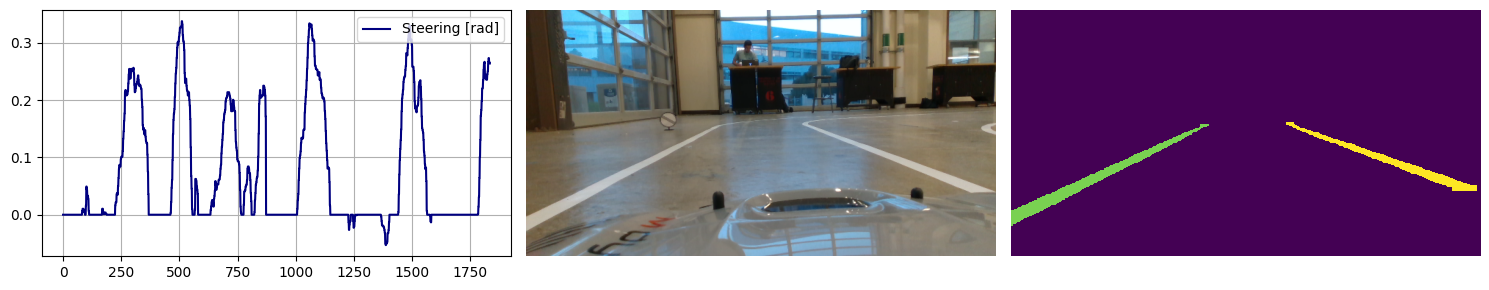


Visible classes:
0 background
4 line_left
5 line_right


In [17]:
# Create a figure with two side-by-side subplots
fig, (ax_left, ax_center, ax_right) = plt.subplots(1, 3, figsize=(15, 3))

# Plot the ground-truth steering angles over time
ax_left.plot(true_angles, color="navy", label="Steering [rad]")
ax_left.grid(True)                    # Add grid for better readability
ax_left.legend(loc="upper right")      # Show legend in the top-left corner

# Display one example camera image from the dataset
ax_center.imshow(images[0], aspect="auto")
ax_center.axis("off") # Hide axes for a clean image view

ax_right.matshow(filtered_masks[0], aspect="auto")
ax_right.axis("off") # Hide axes for a clean image view

# Adjust layout so plots do not overlap
plt.tight_layout()

# Render the figure
plt.show()

# Print which class IDs are present in this mask
print("\nVisible classes:")
for id in np.unique(filtered_masks[0]):   # find all unique values (class IDs)
    print(id, id2label[id])    # map ID → label name

## A simple Lane Follower Pipeline

### Debugging utilities  
These helper functions are used to visualize intermediate results and inspect the internal state of the pipeline.

In [21]:
def draw_box(image, im_canny, corners, color=(0, 255, 0), thickness = 2):

    result = image.copy()

    # Extract the coordinates from the corners tuple
    x1, x2, y1, y2 = corners

    # Draw the box on the image
    cv2.rectangle(result, (x1, y1), (x2, y2), color=color, thickness=thickness)

    # Extract the patch from the grayscale image
    patch = cv2.cvtColor(im_canny, cv2.COLOR_GRAY2RGB)[y1:y2, x1:x2, :]

    # Replace the corresponding region in the RGB image with the patch
    result[y1:y2, x1:x2, :] = patch

    return result

In [22]:
def plot_result(im, mask, corners_l=None, corners_r=None):
    """
    Visualize one frame:
    - shows mask
    - optionally draws left/right tracking windows
    """

    # Convert mask to binary (for drawing)
    binary_mask = (mask > 0).astype(np.uint8) * 255

    # Start with original image
    result = im.copy()

    # Draw left window if provided
    if corners_l is not None:
        result = draw_box(result, binary_mask, corners_l)

    # Draw right window if provided
    if corners_r is not None:
        result = draw_box(result, binary_mask, corners_r)

    # Plot
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))

    axs[0].matshow(mask)
    axs[0].set_title("Mask")
    axs[0].axis("off")

    axs[1].imshow(result)
    axs[1].set_title("Tracking Result")
    axs[1].axis("off")

    plt.show()

### Algorithm building blocks  
This section defines the reusable functions that make up the lane follower.


In [20]:
def get_corners(cx, cy, win_w, win_h, image_w = 640, image_h = 360):
    # Calculate the search window coordinates, ensuring they are within image bounds
    x1 = max(0, int(cx - win_w / 2))
    y1 = max(0, int(cy - win_h / 2))
    x2 = min(image_w, x1 + win_w)
    y2 = min(image_h, y1 + win_h)
    return x1, x2, y1, y2

def preprocess_image(image, canny_min, canny_max, kernel):

    # Convert to grayscale
    im_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply Gaussian blur to the grayscale image
    im_blur = cv2.GaussianBlur(im_gray, kernel, 0)

    # Apply Canny edge detection to the preprocessed image
    im_canny = cv2.Canny(im_blur, canny_min, canny_max) # [0 or 255]

    return im_canny

def update_window(corners, im_canny):
    # Adjust window center by detecting lane line pixels in the image patch
    # Success means pixels were found and a new center is calculated

    x1, x2, y1, y2 = corners

    # Extract the relevant image patch and identify non-zero pixels (lane line pixels)
    patch = im_canny[y1:y2, x1:x2]

    # x2 = x1 + np.searchsorted(np.cumsum(np.sum(patch > 0, axis=0)), 240)
    # patch = im_canny[y1:y2, x1:x2]

    _, xs = np.nonzero(patch)


    # Check if any lane line pixels are detected
    # If not, return False along with the current center
    if len(xs) == 0:
        return False, win_x


    # Calculate the new center based on the mean of the detected pixels
    updated_center = int(x1 + np.mean(xs))

    return True, updated_center

def compute_offset(win_x, half_road_width, veh_xcenter):
    # Estimate the road center from the tracked lane position
    pox_x = win_x - half_road_width

    # Compute how far the vehicle is from the road center (in pixels)
    offset_px = pox_x - veh_xcenter

    # This offset is the control error used for steering
    return offset_px

def predict_steering(offset, kp=1.0, bias=0.0):
    # Proportional controller: map lateral offset to steering angles
    return kp * offset + bias


### Road Follower Setup   
These values control how images are processed and how the lane is tracked in pixel space.

In [29]:
# Image and window
im_width = 640      # image width
im_height = 360     # image height
winx_l = 30        # window x position
winx_r = 580        # window x position
winy = 260          # window y position
win_w = 90          # window width
win_h = 30          # window height

# Vehicle position
veh_xcenter = 380   # vehicle center in image

# Road geometry
road_width_px = 490
half_road_width = road_width_px // 2

# Flag indicating whether initialization parameters are set
reset = True

### Running and inspecting the pipeline  
We run the full algorithm and visualize its internal state to better understand and debug it.

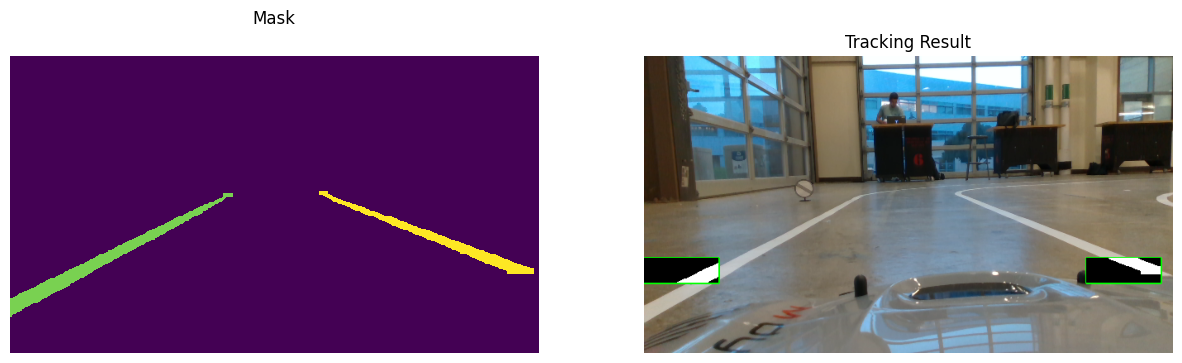

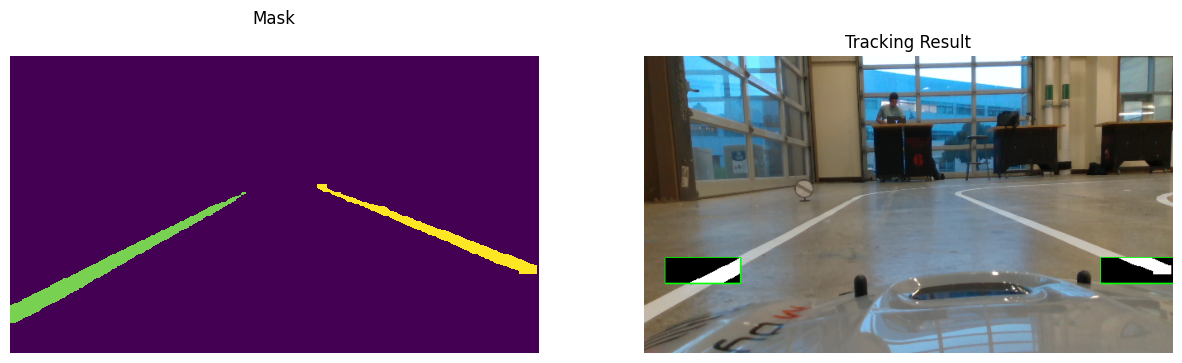

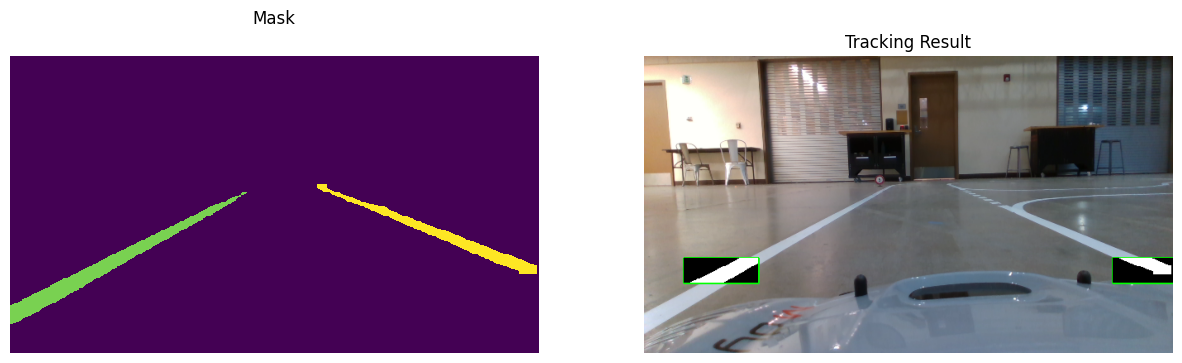

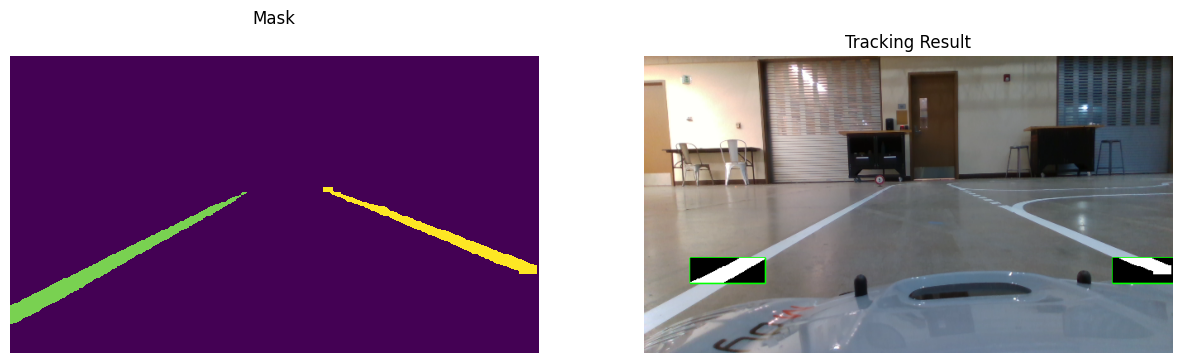

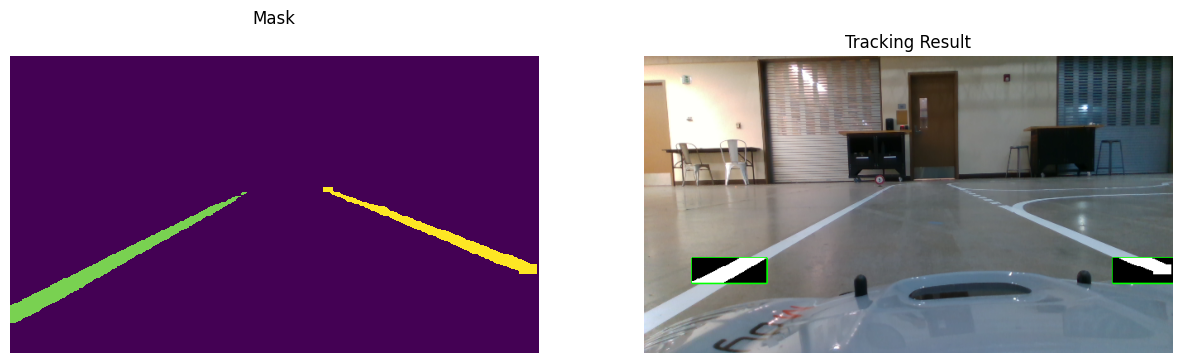

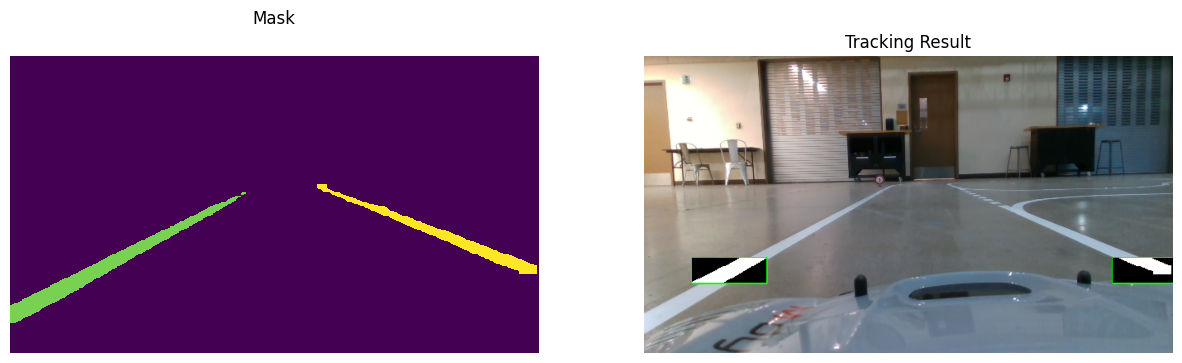

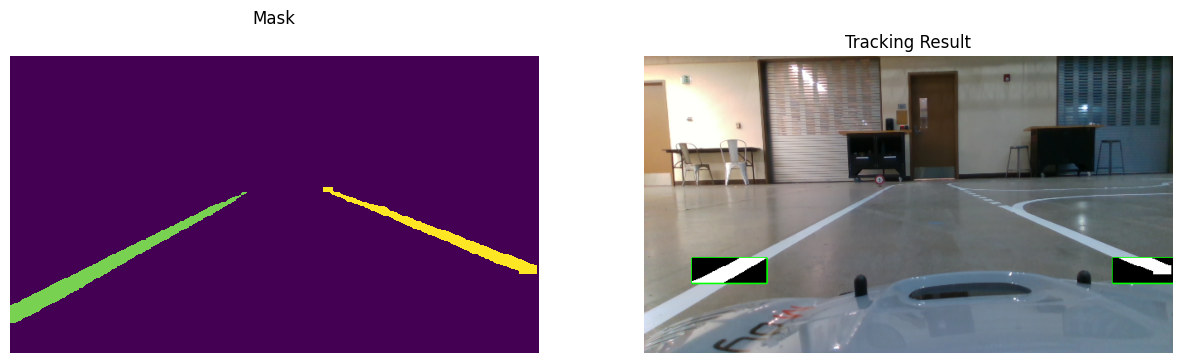

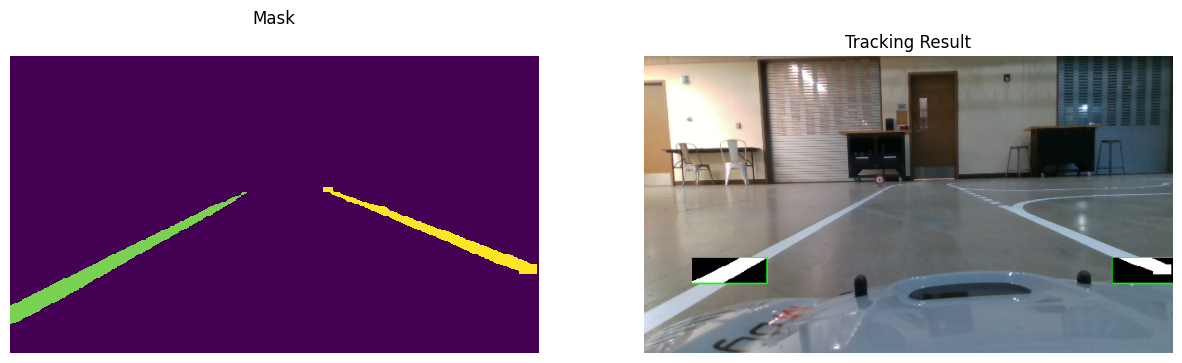

In [30]:
if not reset:
    raise AssertionError("Setup missing: run the road follower setup cell.")

reset = False

state ="straight"

corners_l = None
corners_r = None

predicted_angles = []

for i, (im, mask) in enumerate(zip(images, filtered_masks)):

    # --- 1. Update tracking depending on state ---
    if state == "left_curve":
        # Left curve → follow RIGHT lane
        corners_r = get_corners(winx_r, winy, win_w, win_h, im_width, im_height)
        success_r, winx_r = update_window(corners_r, mask)

        # When tracking the RIGHT lane line → subtract half_road_width
        offset_px = compute_offset(winx_r, half_road_width, veh_xcenter)

    elif state == "right_curve":
        # Right curve → follow LEFT lane
        corners_l = get_corners(winx_l, winy, win_w, win_h, im_width, im_height)
        success_l, winx_l = update_window(corners_l, mask)

        # When tracking the LEFT lane line → add half_road_width (flip the sign)
        offset_px = compute_offset(winx_r, -half_road_width, veh_xcenter)

    else:
        # Straight → update both lanes
        corners_l = get_corners(winx_l, winy, win_w, win_h, im_width, im_height)
        success_l, winx_l = update_window(corners_l, mask)

        corners_r = get_corners(winx_r, winy, win_w, win_h, im_width, im_height)
        success_r, winx_r = update_window(corners_r, mask)

        offset_px = compute_offset(winx_r, half_road_width, veh_xcenter)

    steering_angle = predict_steering(offset_px)
    predicted_angles.append(steering_angle)


    plot_result(im, mask, corners_l=corners_l, corners_r=corners_r)

    if i > 6:
      break # REMOVE

## Evaluating and tuning the controller  
Here we compare the predicted steering to the ground truth and adjust the controller gains.


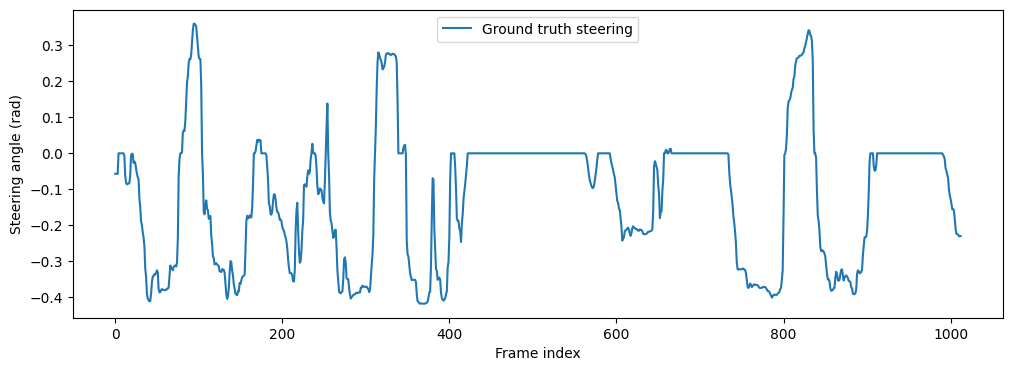

In [127]:
# Proportional gain controlling how strongly we react to lateral error
kp = 7.5e-4

# Constant steering bias (trim) shifting the neutral point
bias = 0.08

tuned_steering = predict_steering(predicted_angles, kp, bias) # steering angle

# Mean Absolute Error between prediction and ground truth
mae = np.nanmean(np.abs(tuned_steering - true_angles))

plt.figure(figsize=(12, 4))
plt.plot(tuned_steering, label="Predicted steering")
plt.plot(true_angles, label="Ground truth steering")
plt.xlabel("Frame index")
plt.ylabel("Steering angle (rad)")
plt.title(f"Steering prediction vs ground truth | MAE = {mae:.2f}")
plt.legend()
plt.show()
